# Indian Stock Market Analysis

## Pre Requisite

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
import yfinance as yf
from pandas_datareader import data as wb

## Nifty 50 (Market Index)

### Basic Data Loading

In [88]:
nf50=yf.download('^NSEI',start='2015-1-1',end='2023-1-1',auto_adjust=False)
nf50=pd.DataFrame(nf50)
nf50.columns = nf50.columns.droplevel("Ticker")
nf50.columns.name = None  # also hides the remaining "Price" heading
nf50.head()

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,8395.450195,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [89]:
nf50.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1968 entries, 2015-01-02 to 2022-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  1968 non-null   float64
 1   Close      1968 non-null   float64
 2   High       1968 non-null   float64
 3   Low        1968 non-null   float64
 4   Open       1968 non-null   float64
 5   Volume     1968 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 107.6 KB


### Returns

In [90]:
nf50['Percreturn']=nf50["Adj Close"].pct_change()
nf50['Logreturn']=np.log(nf50["Adj Close"]/nf50["Adj Close"].shift(1))
nf50.head()

,Adj Close,Close,High,Low,Open,Volume,Percreturn,Logreturn
Date,,,,,,,,
2015-01-02,8395.450195,8395.450195,8410.599609,8288.700195,8288.700195,101900,NaN,NaN
2015-01-05,8378.400391,8378.400391,8445.599609,8363.900391,8407.950195,118200,-0.002031,-0.002033
2015-01-06,8127.350098,8127.350098,8327.849609,8111.350098,8325.299805,172800,-0.029964,-0.030422
2015-01-07,8102.100098,8102.100098,8151.200195,8065.450195,8118.649902,164100,-0.003107,-0.003112
2015-01-08,8234.599609,8234.599609,8243.500000,8167.299805,8191.399902,143800,0.016354,0.016221


Text(0.5, 0, 'Year')

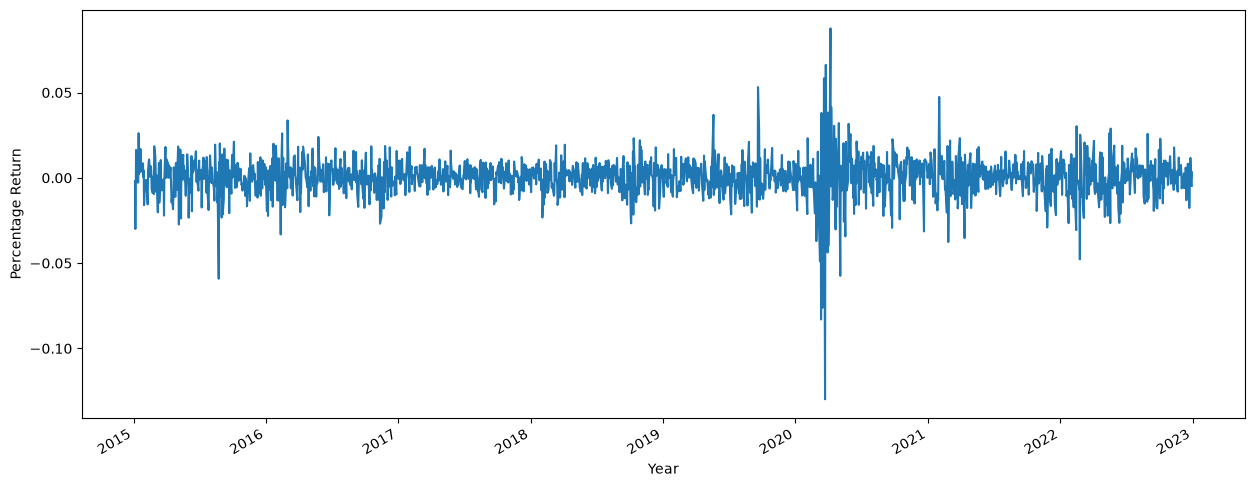

In [91]:
x=nf50['Percreturn'].plot(figsize=(15,6))
x.set_ylabel('Percentage Return')
x.set_xlabel('Year')

Text(0.5, 0, 'Year')

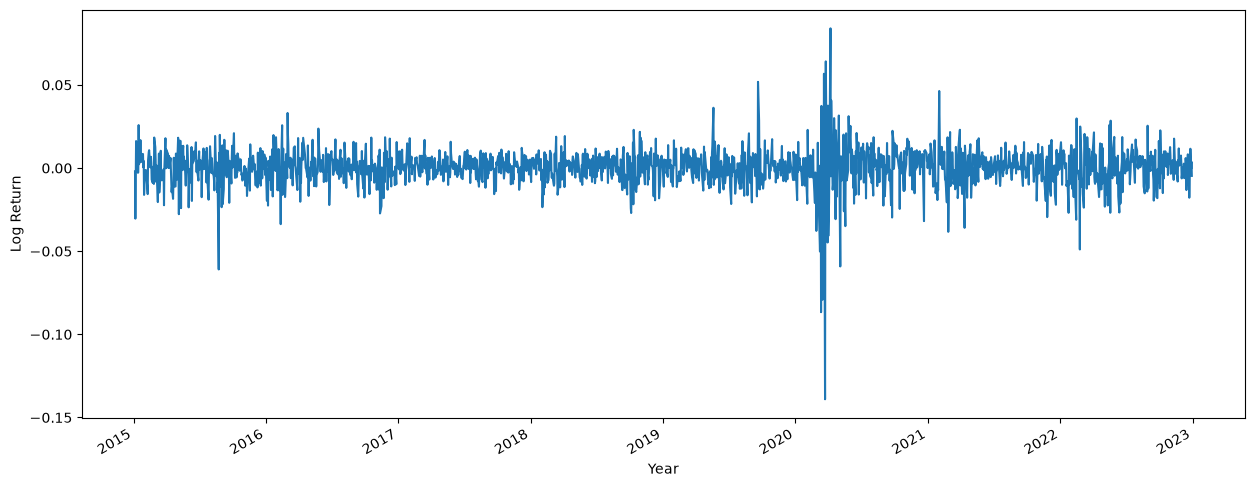

In [92]:
y=nf50['Logreturn'].plot(figsize=(15,6))
y.set_ylabel('Log Return')
y.set_xlabel('Year')

In [93]:
rm=nf50['Percreturn'].mean()
arm=rm*250
lrm=nf50['Logreturn'].mean()
alrm=lrm*250
print(f"Annual Simple Rate of Return:{arm}\nAnnual Logarithmic Rate of Return:{alrm}\n")

Annual Simple Rate of Return:0.11315708848017211
Annual Logarithmic Rate of Return:0.09767600922046937



### The Annual Simple Rate of Return is 
### The Annual Logarithmic Rate of Return is 


### Volatility

In [ ]:
rv=nf50['Percreturn'].std()
arv=rv*250**0.5
lrv=nf50['Logreturn'].std()
alrv=lrv*250**0.5
print(f"Annual Volatility:{arv}\n Annual Logarithmic Volatility:{alrv}\n")

<class 'numpy.float64'>
Annual Volatility:0.17512230416113286
 Annual Logarithmic Volatility:0.17630353340033164



### The Annual Percentage Return Volatility is 
### The Annual Logarithmic Return Volatility is 

### Future Prediction (Monte Carlo Simulation)

 ...]

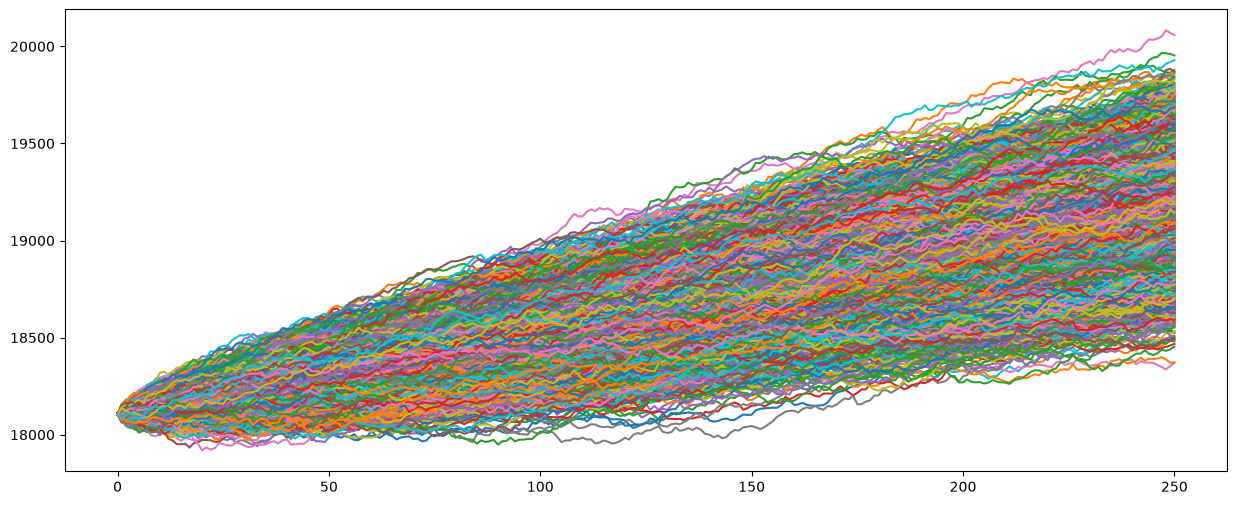

In [ ]:
#Risk Free- Indian Govt Bonds-7% Interest
r=0.0721
st=alrv
iterations=10000
T=1.0
t_interval=250
delta=T/t_interval
z=np.random.standard_normal((t_interval+1,iterations))
s=np.zeros_like(z)
s0=nf50['Adj Close'].iloc[-1]
s[0]=s0
for t in range(1,t_interval+1):
  s[t]=s[t-1]*np.exp((r-0.5*(st**2))*delta+st*delta*z[t])
plt.figure(figsize=(15,6))
plt.plot(s[:,:10])